In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import dotenv

dotenv.load_dotenv()

import xarray as xr
import pandas as pd
import hvplot.xarray
import hvplot.pandas
import numpy as np
from matplotlib import pyplot as plt

import compoundx_figs as cf
from PyCO2SYS.api import CO2SYS_wrap as co2sys

In [3]:
fnames_switch = {
    "aux_vars": "s3://ocean-co2/extremes/aux_vars.zarr/",
    "cexTH": "s3://ocean-co2/extremes/ETHZ1v2025_cexTH_shift_poly2_p95.zarr/",
    "ph_total": "s3://ocean-co2/extremes/ETHZ1v2025_ph_total_Bmean_shift_poly2_p95.zarr/",
    "temperature": "s3://ocean-co2/extremes/ETHZ1v2025_temperature_Bmean_shift_poly2_p95.zarr/",
    "masks": "s3://ocean-co2/extremes/masks.zarr/"
}

In [4]:
ethz = xr.open_zarr(
    "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/ocean-soda/ocean-soda.zarr"
)
aux = xr.open_zarr(fnames_switch["aux_vars"])
masks = xr.open_zarr(fnames_switch["masks"])

1.2875000000000023

In [71]:
cex = xr.open_zarr(fnames_switch["cexTH"])
num_extremes = cex.mask.sum("time").compute() 
w = 800
quantile = 0.95
expected_num_compound_extremes = (1 - quantile) ** 2 * cex.time.size
mlf = num_extremes / expected_num_compound_extremes
(mlf).hvplot.image(width=w, height=int(w / 2), cmap="viridis", )

:Image   [lon,lat]   (mask)

In [95]:
x = mlf.lon.values
lons = np.r_[x[-180:], x, x[:180]]

In [107]:
w = 1000
(
    mlf.sel(lon=lons)
    .where(lambda x: x > 0)
    .rolling(lat=5, lon=5, center=True, min_periods=1)
    .mean()
    .rolling(lat=3, lon=3, center=True, min_periods=1)
    .mean()
    .where(lambda x: x > 0)
    .isel(lon=slice(180, 540))
    # .plot.imshow(robust=True, aspect=2.2, size=5)
    .interp(
        lat=np.arange(-90 + 0.125, 90, 0.25),
        lon=np.arange(-180 + 0.125, 180, 0.25),
        method="linear",
    )
    .pipe(lambda x: x.fillna(x.min()))
    .pipe(lambda x: x - x.min())
    .rolling(lat=11, lon=11, center=True, min_periods=1)
    .mean()
    .rolling(lat=5, lon=5, center=True, min_periods=1)
    .mean()
    # .hvplot.image(width=w, height=int(w / 2), cmap="viridis", clim=(0, 10))
    .to_pandas()
    .to_csv("num_extremes_map_smoothed.csv")
)

In [ ]:
num_extremes.to_pandas().where(lambda x: x > 0).to_csv("num_extremes.csv")

# BATS test detrending

In [608]:
# Latitude:   31.6667     Longitude:   -64.1667
loc = {"lat": 31.6667, "lon": -64.1667}  # the real bats

# loc = {"lat": 40.6667, "lon": -154.1667}

vars = ["talk", "dic", "ph_total", "temperature", "salinity"]

bats = ethz.sel(**loc, method="nearest")[vars]
bats['h'] = 10**(-bats.ph_total) * 1e9
bats["dic_trend"] = cf.extreme_detection.trend_poly(bats.dic, order=2)
bats["alk_trend"] = cf.extreme_detection.trend_poly(bats.talk, order=2)
bats["h_trend"] = cf.extreme_detection.trend_poly(bats.h, order=2)
bats["temp_trend"] = cf.extreme_detection.trend_poly(bats.temperature, order=2)
bats["salt_trend"] = cf.extreme_detection.trend_poly(bats.salinity, order=2)

bats["dic_detrend"] = bats.dic - bats.dic_trend + bats.dic.mean()
bats["alk_detrend"] = bats.talk - bats.alk_trend + bats.talk.mean()
bats["h_detrend"] = bats.h - bats.h_trend + bats.h.mean()
bats["temp_detrend"] = bats.temperature - bats.temp_trend + bats.temperature.mean()
bats["salt_detrend"] = bats.salinity - bats.salt_trend + bats.salinity.mean()

# bats = bats.sel(time=slice("1980", "2019"))
bats = bats.to_pandas()

In [609]:
cex = xr.open_zarr(fnames_switch["cexTH"]).sel(**loc, method="nearest")
oax = xr.open_zarr(fnames_switch["ph_total"]).sel(**loc, method="nearest")
mhw = xr.open_zarr(fnames_switch["temperature"]).sel(**loc, method="nearest")

In [610]:
mhw_mask = mhw.mask.to_pandas()
oax_mask = oax.mask.to_pandas()
cex_mask = cex.mask.to_pandas()


def standardize(series: pd.Series) -> pd.Series:
    return (series - series.mean()) / series.std()


def deseasonalise(series: pd.Series) -> pd.Series:
    deseasonalised = series - series.groupby(pd.to_datetime(series.index).month).transform("mean")
    return deseasonalised


def poly_trend(series: pd.Series, degree: int) -> pd.Series:
    series = series.dropna()
    time = series.index.values.astype("datetime64[ns]").astype(float) / 1e9 / 86400 / 365.25  # convert to years
    coefs = np.polyfit(time, series.values, degree)
    print(coefs)
    return pd.Series(np.polyval(coefs, time), index=series.index)


def detrend_quadratic(series: pd.Series) -> pd.Series:
    linear = poly_trend(series, degree=2)
    detrended = series - linear
    return detrended


def detrend_linear(series: pd.Series) -> pd.Series:
    linear = poly_trend(series, degree=1)
    detrended = series - linear
    return detrended

[ 0.02881309 -0.89304384]
[ 0.02953808 -0.91674496]
[ 6.14305351e-04  1.07470921e-02 -9.97153773e-01]
[ 1.08464302e-03  2.07889417e-02 -1.81991979e+00]


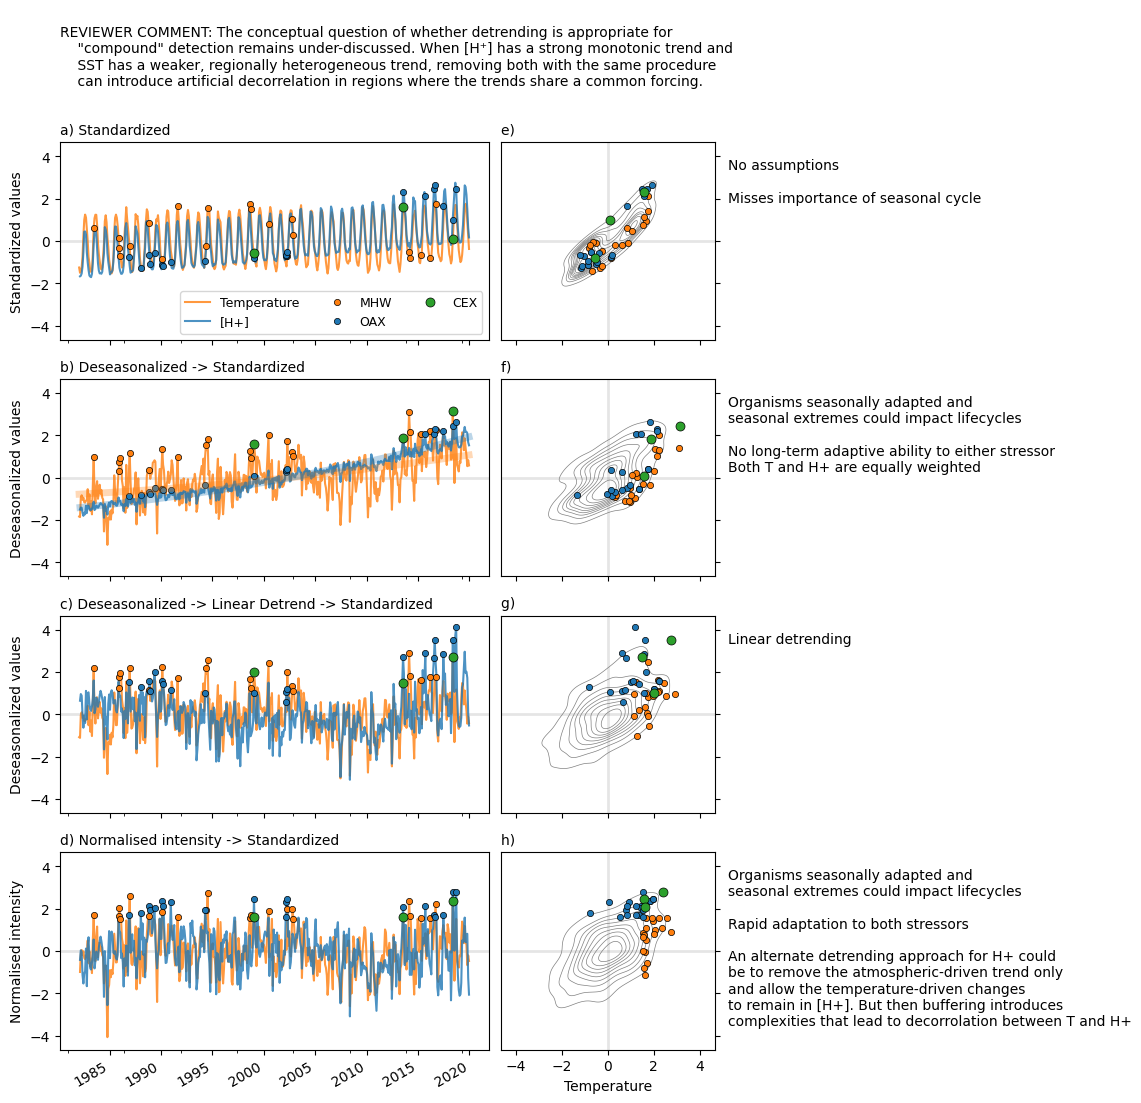

In [611]:
import seaborn as sns
from string import ascii_lowercase

if "collapse figure props":
    title_props = dict(loc="left", size=10)
    axline_props = dict(color="k", lw=2, ls="-", alpha=0.1,)

    line_props = dict(lw=1.5, ls="-", alpha=0.8)
    temp_line_props = dict(color="tab:orange", label="Temperature", **line_props)
    hpls_line_props = dict(color="tab:blue", label="[H+]", **line_props)

    kde_props = dict(color="grey", thresh=0.05, linewidths=0.5)

    extrm_props = dict(lw=0, marker=".", ms=9, mew=0.5, mec='k')
    extrm_mhw_props = dict(color="tab:orange", label="MHW", **extrm_props)
    extrm_oax_props = dict(color="tab:blue", label="OAX", **extrm_props)
    extrm_cex_props = dict(color="tab:green", label="CEX", **(extrm_props | dict(ms=13)))

def plot_lines(a, b, ax, title, ylabel):
    ax.set_title(title, **title_props)
    ax.set_ylabel(ylabel)
    ax.axhline(0, **axline_props)
    a.plot(ax=ax, **temp_line_props)
    b.plot(ax=ax, **hpls_line_props)
def plot_kde(a, b, ax):
    ax.axhline(0, **axline_props)
    ax.axvline(0, **axline_props)
    sns.kdeplot(x=a, y=b, ax=ax, **kde_props)
    ax.set_ylabel("Standardized [H+]")
def plot_extremes(a, b, ax0, ax1, title=""):
    a.where(mhw_mask).plot(ax=ax0, **extrm_mhw_props)
    b.where(oax_mask).plot(ax=ax0, **extrm_oax_props)
    a.where(cex_mask).plot(ax=ax0, **extrm_cex_props)
    ax1.plot(a.where(mhw_mask), b.where(mhw_mask), **extrm_mhw_props)
    ax1.plot(a.where(oax_mask), b.where(oax_mask), **extrm_oax_props)
    ax1.plot(a.where(cex_mask), b.where(cex_mask), **extrm_cex_props)

    lim = abs(np.array([ax1.get_xlim(), ax0.get_ylim(), ax1.get_ylim()])).max() * 1.05
    ax0.set_ylim(-lim, lim)
    ax1.set_xlim(-lim, lim)
    ax1.set_title(title, **title_props)
def plot_row(a, b, ax1, ax2, title1, ylabel1, title2=""):
    plot_lines(a, b, ax1, title1, ylabel1)
    plot_kde(a, b, ax2)
    plot_extremes(a, b, ax1, ax2, title=title2)
def prepend_fig_num(i, title):
    return f"{ascii_lowercase[i]}) {title}"

fig, axs = plt.subplots(4, 2, figsize=(9, 10), width_ratios=[2, 1], sharex="col", sharey=True)
n_rows, n_cols = axs.shape
axs = axs.T.flatten()

period = slice("1982", "2019")
temp = bats.temperature.loc[period]
hpls = bats.h.loc[period]
oax = oax.sel(time=period)
mhw = mhw.sel(time=period)

inputs = [
    dict(
        a=temp.pipe(standardize),
        b=hpls.pipe(standardize),
        title1="Standardized",
        ylabel1="Standardized values",
    ),
    dict(
        a=temp.pipe(deseasonalise).pipe(standardize),
        b=hpls.pipe(deseasonalise).pipe(standardize),
        title1="Deseasonalized -> Standardized",
        ylabel1="Deseasonalized values",
    ),
    dict(
        a=temp.pipe(deseasonalise).pipe(detrend_linear).pipe(standardize),
        b=hpls.pipe(deseasonalise).pipe(detrend_linear).pipe(standardize),
        title1="Deseasonalized -> Linear Detrend -> Standardized",
        ylabel1="Deseasonalized values",
    ),
    dict(
        a=mhw.intensity_norm.pipe(standardize).to_pandas(),
        b=oax.intensity_norm.pipe(standardize).to_pandas(),
        title1="Normalised intensity -> Standardized",
        ylabel1="Normalised intensity",
    ),
]

for i, row in enumerate(inputs): 
    row.update(ax1=axs[i], ax2=axs[i+n_rows], title1=prepend_fig_num(i, row.pop("title1")), title2=prepend_fig_num(i+n_rows, row.pop("title2", "")))
    plot_row(**row)

temp.pipe(deseasonalise).pipe(standardize).pipe(poly_trend, degree=2).plot(ax=axs[1], color="tab:orange", label="Temperature trend", lw=5, ls="-", alpha=0.3)
hpls.pipe(deseasonalise).pipe(standardize).pipe(poly_trend, degree=2).plot(ax=axs[1], color="tab:blue", label="H+ trend", lw=5, ls="-", alpha=0.3)

axs[0].legend(loc="lower right", fontsize=9, ncol=3)
axs[n_rows-1].set_xlabel("")
axs[-1].set_xlabel("Temperature")

for ax in axs[n_rows:]:
    ax.yaxis.tick_right()
    ax.yaxis.set_label_position("right")

fig.tight_layout()
fig.subplots_adjust(right=0.8)

text_props = dict(x=1.06, y=1, va="top", ha="left", fontsize=10)
seasonally_adapted = "Organisms seasonally adapted and\nseasonal extremes could impact lifecycles"
no_longterm_adapt = "No long-term adaptive ability to either stressor\nBoth T and H+ are equally weighted"
rapid_adaptation = "Rapid adaptation to both stressors"
better_detrending = "An alternate detrending approach for H+ could\nbe to remove the atmospheric-driven trend only\nand allow the temperature-driven changes\nto remain in [H+]. But then buffering introduces\ncomplexities that lead to decorrolation between T and H+"

assumptions = [
    "\nNo assumptions\n\nMisses importance of seasonal cycle",
    f"\n{seasonally_adapted}\n\n{no_longterm_adapt}",
    "\nLinear detrending",
    f"\n{seasonally_adapted}\n\n{rapid_adaptation}\n\n{better_detrending}",
]
for text, ax in zip(assumptions, axs[n_rows:]):
    ax.text(s=text, transform=ax.transAxes, **text_props)

fig.suptitle(
    """
REVIEWER COMMENT: The conceptual question of whether detrending is appropriate for 
    "compound" detection remains under-discussed. When [H⁺] has a strong monotonic trend and 
    SST has a weaker, regionally heterogeneous trend, removing both with the same procedure
    can introduce artificial decorrelation in regions where the trends share a common forcing.""",
    x=axs[0].get_position().x0,
    y=1.02,
    ha="left",
    va="bottom",
    fontsize=10,
)
plt.show()

**2. The conceptual question of whether detrending is appropriate for "compound" detection remains under-discussed. When [H⁺] has a strong monotonic trend and SST has a weaker, regionally heterogeneous trend, removing both with the same procedure can introduce artificial decorrelation in regions where the trends share a common forcing.**

Temperature changes are driven by warming / cooling over short and long periods. 
[H+] changes are driven first and foremost by increasing atmospheric CO2. Then by changes in temperature, and then changes in the carbonate system buffering capacity. 
The latter is a much more complex system. 
By detrending temperature quadratically, we're removing the impact of one driver alone - however, there is no evidence that temperature is increasing quadratically. 
By detrending [H+] quadratically, we're removing primarily the atmospheric CO2 trend, but then also some of the impact of temperature, but the dominant part of the trend. 
The long-term behaviour of these two ocean water properties differ substantially. While temperature has shown multi-decadal warming, the rate and timing of the warming differs substantially from region to region. 
In contrast to this, the long-term trend of [H+] has been increasing steadily and predictably, driven by the increases in atmospheric CO2. 
Considering a quadratic fit defined with the following coefficients:
$$
y = a x^2 + b x + c
$$
we can now practically demostrate the impact of separate detrending. Suppose a region experienced warming in the 1980--1990s, whereafter warming stagnated, we would expect $a$ to be negative (i.e., a trend with a peak shape). However, in a different region, the first half of the time series (1980--1990s) experienced no warming, but thereafter intense warming, we would expect $a$ to be positive (i.e., a trend with a trough shape). 
In contrast, the [H+] in most cases would be driven primarily by increasing atmospheric CO2, with the theoretical fit of this curve (excluding the effects of temperature on [H+]) having a positive $a$. 
However, on the time scales at which we do the detrending, it may be that the quadratic nature of CO2 is not always the dominant contributer to the shape of the fit, where temperature and circulation may have stronger impacts. 
In cases where the quadratic coefficient of temperature and [H+] have opposite signs, we could see decorrelations of the detrended data. 


**Way to respond:**
We chose to detrend with a quadratic polynomial - arguably close to a multi-decadal moving average. We made this choice based on the fact that we wanted to remove the dominant trend in [H+]. For simplicty, we applied the same detrending approach to temperature. However, this approach may have implications in scenarios where 


<div style="color:blue">If temperature has an increasing trend, and that imprint is also seen in [H+], detrending [H+] and temperature would remove the impact of the increase in temperature on [H+]. Our approach may thus underreport warming related compound extremes, particularly towards the end of the time series. An alternate approach to detrending [H+] could be to remove only the effect of increasing atmospheric CO2, thus leaving the temperature- (and buffer-related) extremes present in the data. Our results should thus be interpreted as a conservative approach.

<div>


In [ ]:
from PyCO2SYS.api import CO2SYS_wrap as co2sys

bats_computed = co2sys(
    dic=bats.dic_detrend,
    alk=bats.alk_detrend,
    sal=bats.salinity,
    temp_in=bats.temp_detrend,
    si=1,
    po4=0.01,
)
bats_computed.index = bats.index
bats_computed["h"] = 10**(-bats_computed.pHinTOTAL) * 1e9

Convert data to pandas.DataFrame
Removing nans for efficiency
Computing CO2 parameters
Insert nans back into DataFrame


In [22]:
arr = np.array([
    bats.h_detrend.values,
    10**(-bats_computed.pHinTOTAL.values) * 1e9,
    bats.temperature.values,
    bats.temp_detrend.values,
    bats.dic.values,
    bats.dic_detrend.values,
    bats.talk.values,
    bats.alk_detrend.values,]).T

columns = [
    "$D$([H$^+$])",
    "[H$^+$] ← CO2SYS($D$(DIC), $D$(ALK), $D$(T))",
    "T",
    "$D$(T)",
    "DIC",
    "$D$(DIC)",
    "ALK",
    "$D$(ALK)",
]
data = pd.DataFrame(arr, index=bats.index, columns=columns)
data.to_csv("../data/bats_detrended.csv")

In [23]:
from dask.array.wrap import w
blue = "#439fd1"
black = "#000000"
labels = {"xlabel": ""}
img = (
    (
        bats.h_detrend.rename("Φ[H]").hvplot.line()
        * bats_computed.h.rename("pH ← CO2SYS(ΦDIC, ΦALK, ΦTEMP)").hvplot.line(
            color="orange",
            title="pH: direct detrended vs. computed from detrended DIC, ALK, TEMP",
        )
    )
    + (
        bats.temperature.rename("TEMP").hvplot.line(color=black)
        * bats.temp_detrend.rename("ΦTEMP").hvplot.line(
            color=blue, title="Temperature: raw vs. detrended"
        )
    )
    + (
        bats.dic.rename("DIC").hvplot.line(color=black)
        * bats.dic_detrend.rename("ΦDIC").hvplot.line(color=blue, title="DIC: raw vs. detrended")
    )
    + (
        bats.talk.rename("ALK").hvplot.line(color=black, xlabel="")
        * bats.alk_detrend.rename("ΦALK").hvplot.line(
            color=blue, title="ALK: raw vs. detrended", xlabel=""
        )
    )
).cols(2)
img

:Layout
   .Overlay.I   :Overlay
      .Curve.Φ_left_square_bracket_H_right_square_bracket                                             :Curve   [time]   (Φ[H])
      .Curve.PH_leftwards_arrow_CO2SYS_left_parenthesis_ΦDIC_comma_ΦALK_comma_ΦTEMP_right_parenthesis :Curve   [time]   (pH ← CO2SYS(ΦDIC, ΦALK, ΦTEMP))
   .Overlay.II  :Overlay
      .Curve.TEMP  :Curve   [time]   (TEMP)
      .Curve.ΦTEMP :Curve   [time]   (ΦTEMP)
   .Overlay.III :Overlay
      .Curve.DIC  :Curve   [time]   (DIC)
      .Curve.ΦDIC :Curve   [time]   (ΦDIC)
   .Overlay.IV  :Overlay
      .Curve.ALK  :Curve   [time]   (ALK)
      .Curve.ΦALK :Curve   [time]   (ΦALK)

## BATS detrended: 2×2 variable-pair figure

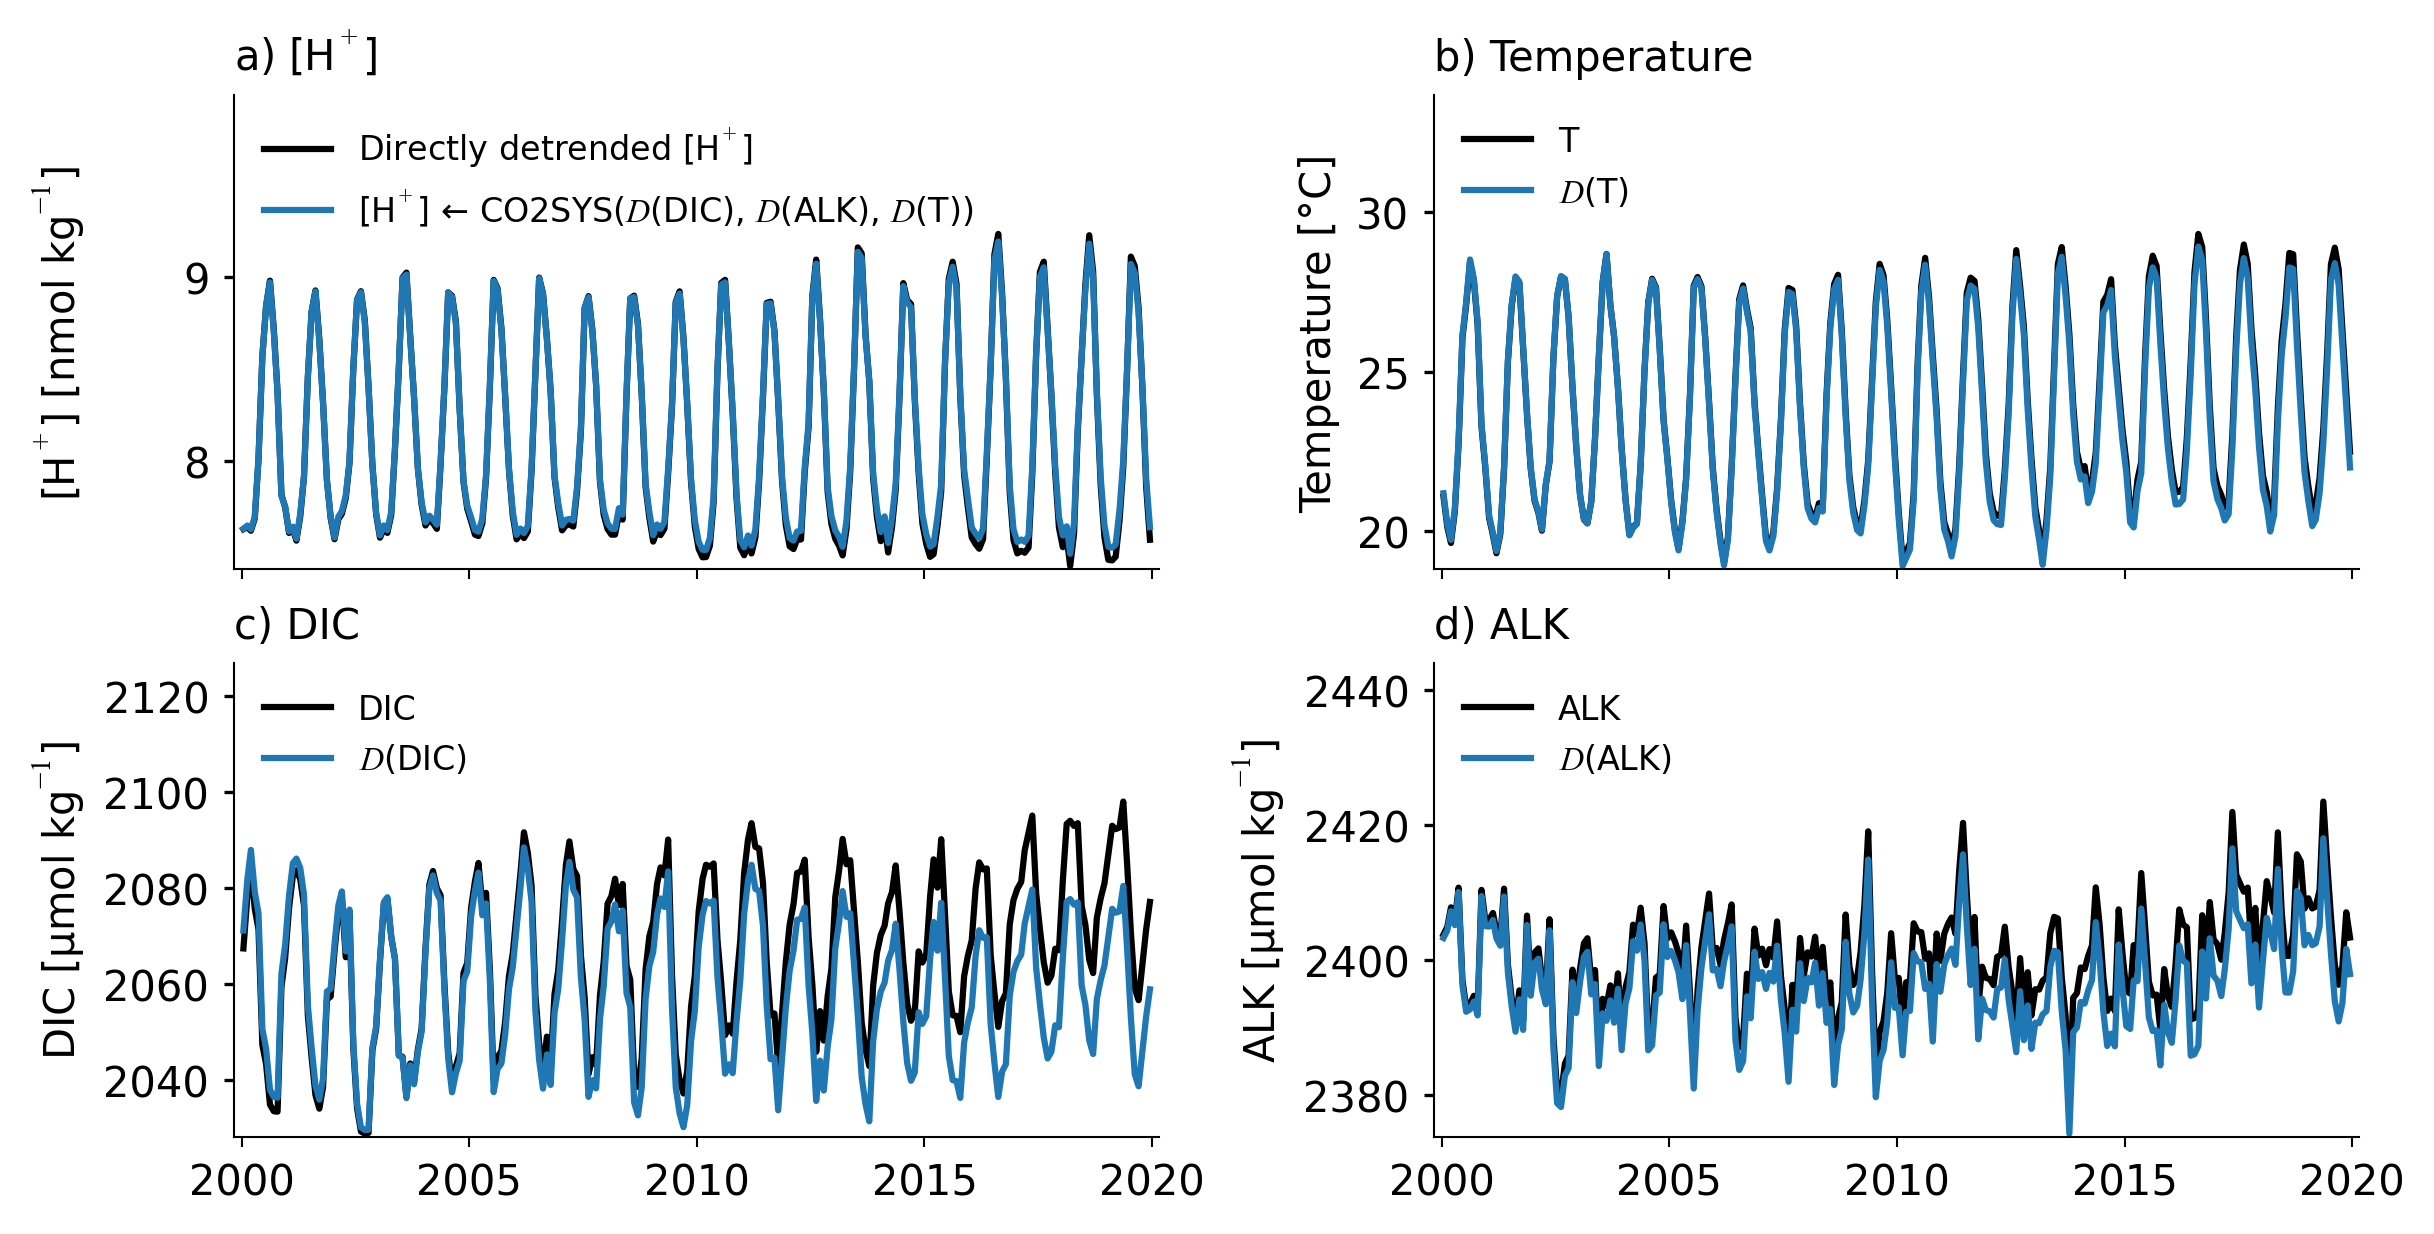

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.style.use("./plotting.mplstyle")

df = pd.read_csv("../data/bats_detrended.csv", index_col="time", parse_dates=True)

panels = [
    dict(
        raw="$D$([H$^+$])",
        det="[H$^+$] ← CO2SYS($D$(DIC), $D$(ALK), $D$(T))",
        raw_label="Directly detrended [H$^+$]",
        det_label="[H$^+$] ← CO2SYS($D$(DIC), $D$(ALK), $D$(T))",
        title="a) [H$^+$]",
        ylabel="[H$^+$] [nmol kg$^{-1}$]",
    ),
    dict(
        raw="T",
        det="$D$(T)",
        raw_label="T",
        det_label="$D$(T)",
        title="b) Temperature",
        ylabel="Temperature [°C]",
    ),
    dict(
        raw="DIC",
        det="$D$(DIC)",
        raw_label="DIC",
        det_label="$D$(DIC)",
        title="c) DIC",
        ylabel="DIC [μmol kg$^{-1}$]",
    ),
    dict(
        raw="ALK",
        det="$D$(ALK)",
        raw_label="ALK",
        det_label="$D$(ALK)",
        title="d) ALK",
        ylabel="ALK [μmol kg$^{-1}$]",
    ),
]

fig, axs = plt.subplots(2, 2, figsize=(8, 4), sharex=True, constrained_layout=True)

for ax, p in zip(axs.flat, panels):
    ax.plot(df.index, df[p["raw"]], color="k", lw=1.5, label=p["raw_label"])
    ax.plot(df.index, df[p["det"]], color="#1f77b4", lw=1.5, label=p["det_label"])
    ax.set_title(p["title"], loc="left", size=10)
    ax.set_ylabel(p["ylabel"])
    ax.legend(loc="upper left", fontsize=8)
    y0, y1 = ax.get_ylim()
    y1 = y1 + (y1 - y0) * 0.4
    ax.set_ylim(y0, y1)

for ax in axs[1]:
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

fig.align_ylabels(axs[:, 0])
# fig.suptitle("BATS time series: raw vs. detrended", size=12, y=1.04, x=axs[0, 0].get_position().x0 + 0.03, ha="left")
fig.savefig("../figures/figureA11.pdf", bbox_inches="tight")
fig.savefig("../figures/figureA11.png", bbox_inches="tight", dpi=150)
plt.show()

In [30]:
(df[panels[0]["raw"]] - df[panels[0]["det"]]).hvplot(line_width=4)

:Curve   [time]   (0)

# Second point

In [174]:
fname_hplus = "../data/v2025/ETHZ1v2025_hplus_Bmean_shift_poly2_p95.nc"
fname_temp = "../data/v2025/ETHZ1v2025_temperature_Bmean_shift_poly2_p95.nc"
hplus = xr.open_dataset(fname_hplus).data.compute().chunk({"time": 12, "lat": 90, "lon": 90}).persist()
temp = xr.open_dataset(fname_temp).data.compute().chunk({"time": 12, "lat": 90, "lon": 90}).persist()

In [137]:
def combine_arrays(hplus: xr.DataArray, temp: xr.DataArray) -> pd.DataFrame:
    from dask.diagnostics import ProgressBar

    ds = xr.merge([hplus.rename("[H+]"), temp.rename("SST")], compat="override")
    with ProgressBar():
        df = ds.to_dask_dataframe().dropna().compute()

    return df

def plot_hist2d(a, b, ax=None, **props):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4), dpi=90)
    else:
        fig = ax.figure

    defaults = dict(cmap="CMRmap_r", norm=plt.matplotlib.colors.LogNorm())
    defaults.update(props)
    ax.hist2d(a, b, **defaults)
    ax.axhline(0, color="k", lw=0.5, ls="--")
    ax.axvline(0, color="k", lw=0.5, ls="--")

    return fig, ax


def calc_anoms(da, anom_func):
    clim = anom_func(da)
    return da - clim


def get_anoms(hplus, temp, anom_func):
    hplus_anom = calc_anoms(hplus, anom_func)
    temp_anom = calc_anoms(temp, anom_func)

    return combine_arrays(hplus_anom, temp_anom)

In [ ]:
def anom_ltm_func(da): return da.mean("time")
def anom_seas_func(da): return da.compute().groupby("time.month").mean("time").sel(month=da.time.dt.month)
def linear_detrend(da): return cf.extreme_detection.trend_poly(da, order=1)
def linear_seas_detrend(da):
    seas = da.compute().groupby("time.month").mean("time").pipe(lambda x: x - x.mean("month")).sel(month=da.time.dt.month)
    trend = cf.extreme_detection.trend_poly(da, order=1)
    return seas + trend


anoms_ltm = get_anoms(hplus, temp, anom_ltm_func)
anoms_seas = get_anoms(hplus, temp, anom_seas_func)
anoms_linear = get_anoms(hplus, temp, linear_detrend)
anoms_seas_linear = get_anoms(hplus, temp, linear_seas_detrend)

[########################################] | 100% Completed | 9.74 s


In [176]:
hplus_mag = xr.open_dataset(fname_hplus).magnitude.compute()
temp_mag = xr.open_dataset(fname_temp).magnitude.compute()
anoms_seas_linear = combine_arrays(hplus_mag, temp_mag)

[########################################] | 100% Completed | 1.91 sms


(<Figure size 900x720 with 4 Axes>, <Axes: >)

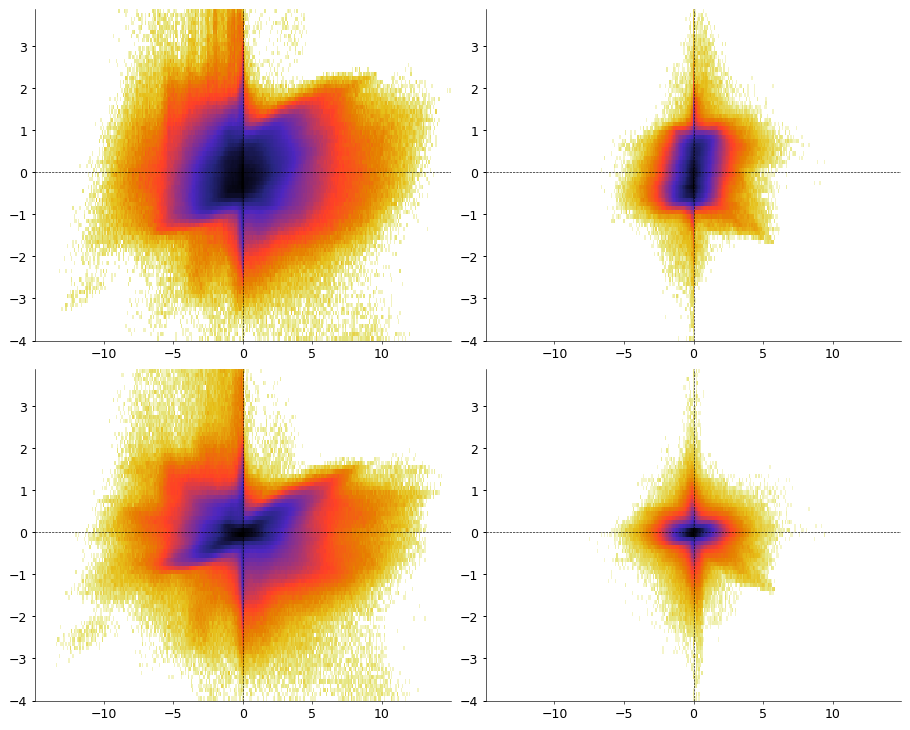

In [177]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8), dpi=90, constrained_layout=True)

plot_hist2d(
    anoms_ltm["SST"],
    anoms_ltm["[H+]"],
    ax=axs[0, 0],
    bins=[np.arange(-15 + 0.05, 15, 0.1), np.arange(-4, 4, 0.1)],
)

plot_hist2d(
    anoms_seas["SST"],
    anoms_seas["[H+]"],
    ax=axs[0, 1],
    bins=[np.arange(-15 + 0.05, 15, 0.1), np.arange(-4, 4, 0.1)],
)


plot_hist2d(
    anoms_linear["SST"],
    anoms_linear["[H+]"],
    ax=axs[1, 0],
    bins=[np.arange(-15 + 0.05, 15, 0.1), np.arange(-4, 4, 0.1)],
)

plot_hist2d(
    anoms_seas_linear["SST"],
    anoms_seas_linear["[H+]"],
    ax=axs[1, 1],
    bins=[np.arange(-15 + 0.05, 15, 0.1), np.arange(-4, 4, 0.1)],
)

In [612]:
bats.temperature.loc["1982":"1990"].groupby(bats.loc["1982":"1990"].index.year).mean()

time
1982    22.930620
1983    23.181175
1984    22.713661
1985    23.108078
1986    23.475382
1987    23.117210
1988    23.254278
1989    23.555885
1990    23.659134
Name: temperature, dtype: float32

In [613]:
from PyCO2SYS.api import CO2SYS_wrap as co2sys

temp_1982 = pd.Series(
    np.tile(
        bats.temperature.loc["1982":"1990"].groupby(bats.loc["1982":"1990"].index.month).mean(),
        len(bats.index.year.unique()),
    ),
    index=bats.index,
)

bats_computed = co2sys(
    dic=bats.dic,
    alk=bats.talk,
    sal=bats.salinity,
    temp_in=bats.temperature,
    temp_out=temp_1982,
    si=1,
    po4=0.01,
)
bats_computed.index = bats.index
bats_computed["h"] = 10 ** (-bats_computed.pHinTOTAL) * 1e9


Convert data to pandas.DataFrame
Removing nans for efficiency
Computing CO2 parameters
Insert nans back into DataFrame


In [614]:
hplus_temp_in = 10**(-bats_computed.pHin) * 1e9
hplus_temp_out = 10**(-bats_computed.pHout) * 1e9

In [615]:
def get_decade_slope(ser):
    return ser.to_xarray().groupby("time.year").mean().polyfit(dim="year", deg=1).polyfit_coefficients[0].item() * 10

In [618]:
slopes = dict(
    full=hplus_temp_in.pipe(get_decade_slope),
    nonthermal=hplus_temp_out.pipe(get_decade_slope),
    thermal=(hplus_temp_in - hplus_temp_out).pipe(get_decade_slope)
)
slopes['resid'] = slopes["full"] - slopes["nonthermal"] - slopes["thermal"]
slopes = pd.Series(slopes).round(3)
(slopes / slopes.full * 100).round()

full          100.0
nonthermal     75.0
thermal        25.0
resid          -0.0
dtype: float64